In [1]:
from pathlib import Path
import sys

dirpath_root = Path().resolve().parents[2]
sys.path.append(str(dirpath_root))
print(dirpath_root)

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

/ddn/niknovikov19/repo/A1_OUinp


In [2]:
def fit_sinusoid_fixed_freq(rr, osc_f, osc_t0):
    tt = np.asarray(rr.time.values, dtype=float)
    yy = np.asarray(rr.values, dtype=float)
    mask = tt >= osc_t0
    tt = tt[mask]
    yy = yy[mask]
    phase = 2 * np.pi * float(osc_f) * (tt - float(osc_t0))
    X = np.column_stack([
        np.sin(phase),
        np.cos(phase),
        np.ones_like(phase),
    ])
    coef, _, _, _ = np.linalg.lstsq(X, yy, rcond=None)
    a_sin, a_cos, offset = coef
    yfit = a_sin * np.sin(phase) + a_cos * np.cos(phase) + offset
    z_out = a_cos - 1j * a_sin
    return tt, yfit, z_out, float(offset)


def print_transfer_coeffs(rates_xr, pops_vis):
    osc_t0 = float(rates_xr.attrs['OSC_T0'])
    osc_f = float(rates_xr.attrs['OSC_F'])
    osc_amp = float(rates_xr.attrs['OSC_AMP'])
    if osc_amp == 0:
        raise ValueError('OSC_AMP is zero, transfer coefficient is undefined')

    z_in = -1j * osc_amp
    print(f'OSC_T0 = {osc_t0}')
    print(f'OSC_F = {osc_f}')
    print(f'OSC_AMP = {osc_amp}')
    print('Transfer coefficients:')
    fit_data = {}
    for pop in pops_vis:
        rr = rates_xr.sel(pop=pop)
        tt_fit, yfit, z_out, offset = fit_sinusoid_fixed_freq(rr, osc_f, osc_t0)
        H = z_out / z_in
        fit_data[pop] = (tt_fit, yfit)
        print(
            f'  {pop}: H = {H.real:+.6g}{H.imag:+.6g}j '
            f'|H| = {abs(H):.6g} phase = {np.angle(H):.6g} rad '
            f'offset = {offset:.6g}'
        )
    return fit_data

Loading: /ddn/niknovikov19/repo/A1_OUinp/exp_results/batch_rxbkg_unconn_state1_mech1/net_inpsur_rr_osc_var_seed_pre_f_amp/exp_rr_osc_pre_post_L2_nseed_1_npre_5_nf_1_namp_1_t_5.0_20.0_osc_t0_5000_ictrl_wmult_0.25_ee_0.5/rvec_xr/rvec_00000_seed_1000_rpre_IT2_f_5_amp_15.nc


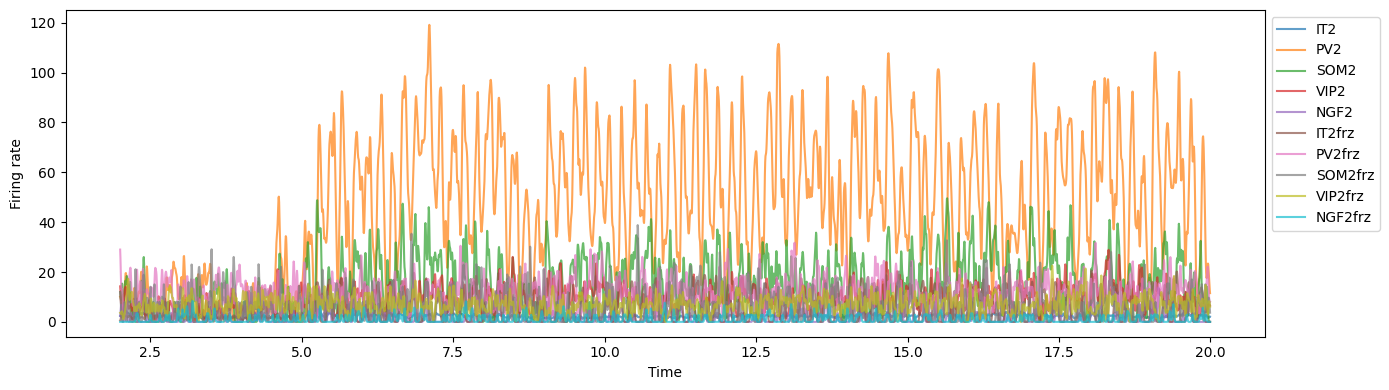

In [23]:
EXP_NAME_BASE = 'batch_rxbkg_unconn_state1_mech1'
EXP_NAME = 'net_inpsur_rr_osc_var_seed_pre_f_amp'

EXP_NAME_SUB = 'exp_rr_osc_pre_post_L2_nseed_1_npre_5_nf_1_namp_1_t_5.0_20.0_osc_t0_5000_ictrl_wmult_0.25_ee_0.5'
JOB_NAME = 'rvec_00000_seed_1000_rpre_IT2_f_5_amp_15'
#JOB_NAME = 'rvec_00001_seed_1000_rpre_PV2_f_5_amp_15'
#JOB_NAME = 'rvec_00002_seed_1000_rpre_SOM2_f_5_amp_15'

fpath_in = (dirpath_root / 'exp_results' / EXP_NAME_BASE / EXP_NAME / 
            EXP_NAME_SUB / 'rvec_xr' / f'{JOB_NAME}.nc')
print(f'Loading: {fpath_in}')

rates_xr = xr.load_dataarray(fpath_in)
pops_vis = [
    pop for pop in rates_xr.pop.values
    #if 'frz' in pop
    #if pop in ['IT2frz', 'PV2frz']
    #if pop in ['IT2frz', 'IT2']
]
#fit_data = print_transfer_coeffs(rates_xr, pops_vis)

osc_t0 = float(rates_xr.attrs['OSC_T0']) / 1000
osc_f = float(rates_xr.attrs['OSC_F'])
osc_amp = float(rates_xr.attrs['OSC_AMP'])

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.figure(figsize=(14, 4))
for n, pop in enumerate(pops_vis):
    rr = rates_xr.sel(pop=pop)
    col = colors[n % len(colors)]
    plt.plot(rr.time.values, rr.values, label=pop, color=col, alpha=0.7)

    #tt_fit, yfit = fit_data[pop]
    #tt_fit, yfit, z_out, offset = fit_sinusoid_fixed_freq(rr, osc_f, osc_t0)
    #plt.plot(tt_fit, yfit, '-', color=col, alpha=1, linewidth=2)

plt.xlabel('Time')
plt.ylabel('Firing rate')
#plt.xlim(10, 17)
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [29]:
t0 = 5
epoch_len = 0.6

R = rates_xr.sel(time=rates_xr.time > t0)
tt = R.time.values

dt = float(np.median(np.diff(tt)))
n_per_epoch = int(round(epoch_len / dt))
n_epochs = R.sizes['time'] // n_per_epoch
t_in_epoch = np.arange(n_per_epoch) * dt

all_epochs = []
for pop in R.pop.values:
    yy = R.sel(pop=pop).values
    yy_cut = yy[: n_epochs * n_per_epoch]
    yy_ep = yy_cut.reshape(n_epochs, n_per_epoch)
    all_epochs.append(yy_ep.mean(axis=0))

rr_epoch_mean = xr.DataArray(
    np.array(all_epochs),
    dims=["pop", "time"],
    coords={"pop": R.pop.values, "time": t_in_epoch},
    name="rr_epoch_mean",
    attrs={"t0": t0, "epoch_len_s": epoch_len, "n_epochs": int(n_epochs)},
)

print(f"dt={dt:.6f} s, n_per_epoch={n_per_epoch}, n_epochs={n_epochs}")
rr_epoch_mean

dt=0.005000 s, n_per_epoch=120, n_epochs=24


<xarray.DataArray 'rr_epoch_mean' (pop: 10, time: 120)> Size: 10kB
array([[ 2.37479075,  2.35547495,  2.34808231, ...,  2.30856147,
         2.34663698,  2.36811366],
       [30.9957225 , 31.77471686, 33.40318647, ..., 35.05809456,
        33.60608488, 32.91665208],
       [10.87564576, 12.0830944 , 13.301271  , ...,  8.08606681,
         8.87811084,  9.89866676],
       ...,
       [ 5.37401441,  5.08411681,  4.7674878 , ...,  5.96592625,
         5.99808208,  5.78766549],
       [ 7.504558  ,  7.11141881,  6.71407529, ...,  7.74067598,
         8.16570213,  8.3851837 ],
       [ 0.89953871,  0.94687418,  1.02898837, ...,  1.31854645,
         1.22474786,  1.09040926]], shape=(10, 120))
Coordinates:
  * pop      (pop) object 80B 'IT2' 'PV2' 'SOM2' ... 'VIP2frz' 'NGF2frz'
  * time     (time) float64 960B 0.0 0.005 0.01 0.015 ... 0.58 0.585 0.59 0.595
Attributes:
    t0:           5
    epoch_len_s:  0.6
    n_epochs:     24

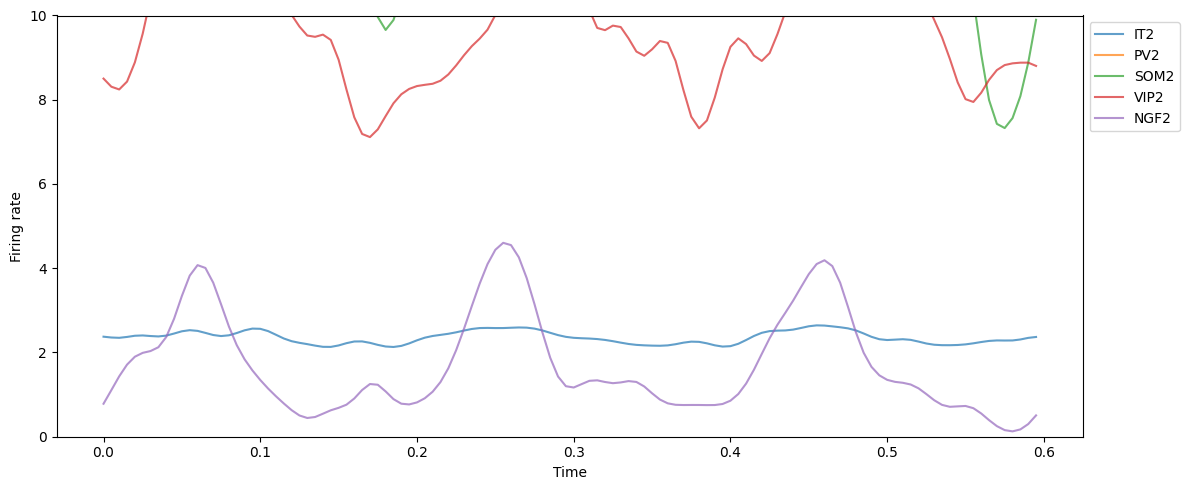

In [31]:
pops_vis = [
    pop for pop in rates_xr.pop.values
    if 'frz' not in pop
    #if pop in ['IT2frz', 'PV2frz']
    #if pop in ['IT2frz', 'IT2']
]

plt.figure(figsize=(12, 5))
for n, pop in enumerate(pops_vis):
    rr = rr_epoch_mean.sel(pop=pop)
    col = colors[n % len(colors)]
    plt.plot(rr.time.values, rr.values, label=pop, color=col, alpha=0.7)

    #tt_fit, yfit = fit_data[pop]
    #tt_fit, yfit, z_out, offset = fit_sinusoid_fixed_freq(rr, osc_f, osc_t0)
    #plt.plot(tt_fit, yfit, '-', color=col, alpha=1, linewidth=2)

plt.xlabel('Time')
plt.ylabel('Firing rate')
plt.ylim(0, 10)
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [4]:
EXP_NAME_SUB = 'exp_hr_osc_L2_nseed_5_nf_1_namp_20_t_5.0_20.0_osc_t0_5000_ictrl_wmult_0.25_ee_0.5'
fpath_in = dirpath_root / 'exp_results' / EXP_NAME_BASE / EXP_NAME / EXP_NAME_SUB / 'rvec_xr_combined.nc'
print(fpath_in)

R = xr.load_dataarray(fpath_in)
R

/home/nnovikov/repo/A1-OUinp/exp_results/batch_rxbkg_unconn_state1_mech1/net_inpsur_hr_osc_var_seed_f_amp/exp_hr_osc_L2_nseed_5_nf_1_namp_20_t_5.0_20.0_osc_t0_5000_ictrl_wmult_0.25_ee_0.5/rvec_xr_combined.nc


<xarray.DataArray (seed_main: 5, osc_f: 1, osc_amp: 20, pop: 5, time: 3600)> Size: 14MB
array([[[[[2.41079035e+00, 2.49926466e+00, 2.57028548e+00, ...,
           2.17067384e+00, 1.91226046e+00, 1.74544963e+00],
          [1.08360812e+01, 1.13504182e+01, 1.14408106e+01, ...,
           7.05866510e+00, 8.11518881e+00, 8.80366309e+00],
          [1.19010606e+01, 1.06580219e+01, 8.47184085e+00, ...,
           8.86385269e-02, 1.74539608e-02, 2.67665158e-03],
          [7.45873512e+00, 6.71709132e+00, 5.41869676e+00, ...,
           1.52870671e+00, 8.38871654e-01, 4.47003279e-01],
          [1.66828899e+00, 2.35912353e+00, 3.24094040e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

         [[1.75976823e+00, 1.85765135e+00, 1.93359375e+00, ...,
           9.53827479e-01, 8.28068423e-01, 7.57912494e-01],
          [6.53240495e+00, 7.09946990e+00, 7.77476292e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [7.42989705e+00, 8.12126867e+00, 8.32955809e+00, ...,
           8.86385269e-02, 1.74539608e-02, 2.67665158e-03],
          [2.49225008e+00, 2.99202701e+00, 3.75622640e+00, ...,
           2.56643245e+00, 1.73228768e+00, 1.18010258e+00],
          [9.14593752e+00, 8.97728986e+00, 8.82587249e+00, ...,
...
          [5.90962685e-01, 1.16626339e+00, 2.28338149e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [1.27331602e+01, 1.23733475e+01, 1.13873334e+01, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [3.33657798e+00, 4.71824706e+00, 6.48188080e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

         [[3.12510129e+00, 3.11860110e+00, 3.07223714e+00, ...,
           3.25293831e-01, 4.28283013e-01, 4.98684443e-01],
          [5.50157882e-01, 1.03039846e+00, 1.86805906e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [4.69388008e+00, 3.71362706e+00, 2.32729719e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
          [1.66828899e+00, 2.35912353e+00, 3.24094040e+00, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]]]],
      shape=(5, 1, 20, 5, 3600))
Coordinates:
  * seed_main  (seed_main) int64 40B 1000 1001 1002 1003 1004
  * osc_f      (osc_f) int64 8B 5
  * osc_amp    (osc_amp) float64 160B 0.01 0.012 0.014 0.017 ... 0.21 0.251 0.3
  * time       (time) float64 29kB 2.0 2.005 2.01 2.015 ... 19.98 19.99 20.0
  * pop        (pop) object 40B 'IT2' 'PV2' 'SOM2' 'VIP2' 'NGF2'
    job_id     (seed_main, osc_f, osc_amp) int64 800B 0 1 2 3 4 ... 96 97 98 99
Attributes:
    OSC_T0:      5000.0
    OSC_F:       5.0
    OSC_AMP:     0.01
    t_limits:    __json__:[2.0,19.995]
    tau_smooth:  0.01
    exp_label:   hr_osc_L2
    seed_main:   1000
    cache_info:  __json__:{"cache_id":"bf6a04d3f8af","cache_version":1,"param...
    proc_steps:  __json__:[{"name":"collect_batch_xr","params":{"data_type":"...

In [16]:
def fit_transfer_coeff_trace(rr, tt, osc_f, osc_amp, fmult, *, osc_t0):
    tt = np.asarray(tt, dtype=float)
    yy = np.asarray(rr, dtype=float)
    mask = tt >= float(osc_t0)
    tt = tt[mask]
    yy = yy[mask]
    phase = 2 * np.pi * float(osc_f * fmult) * (tt - float(osc_t0))
    X = np.column_stack([
        np.sin(phase),
        np.cos(phase),
        np.ones_like(phase),
    ])
    coef, _, _, _ = np.linalg.lstsq(X, yy, rcond=None)
    a_sin, a_cos, _ = coef
    z_out = a_cos - 1j * a_sin
    z_in = -1j #* float(osc_amp)
    return np.complex128(z_out / z_in)

fmult_vals = [1, 2]

osc_t0 = float(R.attrs['OSC_T0']) / 1000
fmult = xr.DataArray(fmult_vals, dims=['fmult'], coords={'fmult': fmult_vals})
Q = xr.apply_ufunc(
    fit_transfer_coeff_trace,
    R,
    R['time'],
    R['osc_f'],
    R['osc_amp'],
    fmult,
    input_core_dims=[['time'], ['time'], [], [], []],
    output_core_dims=[[]],
    vectorize=True,
    output_dtypes=[np.complex128],
    kwargs={'osc_t0': osc_t0},
)
Q.name = 'Q'
Q.attrs['description'] = 'Complex transfer coefficient fit for each non-time slice of R'
Q.attrs['osc_t0_fit'] = osc_t0
Q.attrs['fmult_values'] = [1, 2, 3]

osc_t0 = float(R.attrs['OSC_T0']) / 1000
Q_fit = Q.sel(fmult=Q.fmult != 0) if ('fmult' in Q.dims and 0 in Q.fmult.values) else Q
Q0 = (
    R.where(R.time >= osc_t0)
    .mean(dim='time')
    .astype(np.complex128)
    .expand_dims(fmult=[0])
)
Q0.attrs['description'] = 'Mean R over time for time >= osc_t0, stored as complex with zero imaginary part'
Q = xr.concat([Q0, Q_fit], dim='fmult').sortby('fmult')

Qnorm = Q.copy()
Qnorm /= Qnorm.osc_amp

Qrel = Q.copy()
for fmult in Qrel.fmult:
    if fmult != 1:
        Qrel.loc[{'fmult': fmult}] /= np.abs(Qrel.sel(fmult=1))

#Q


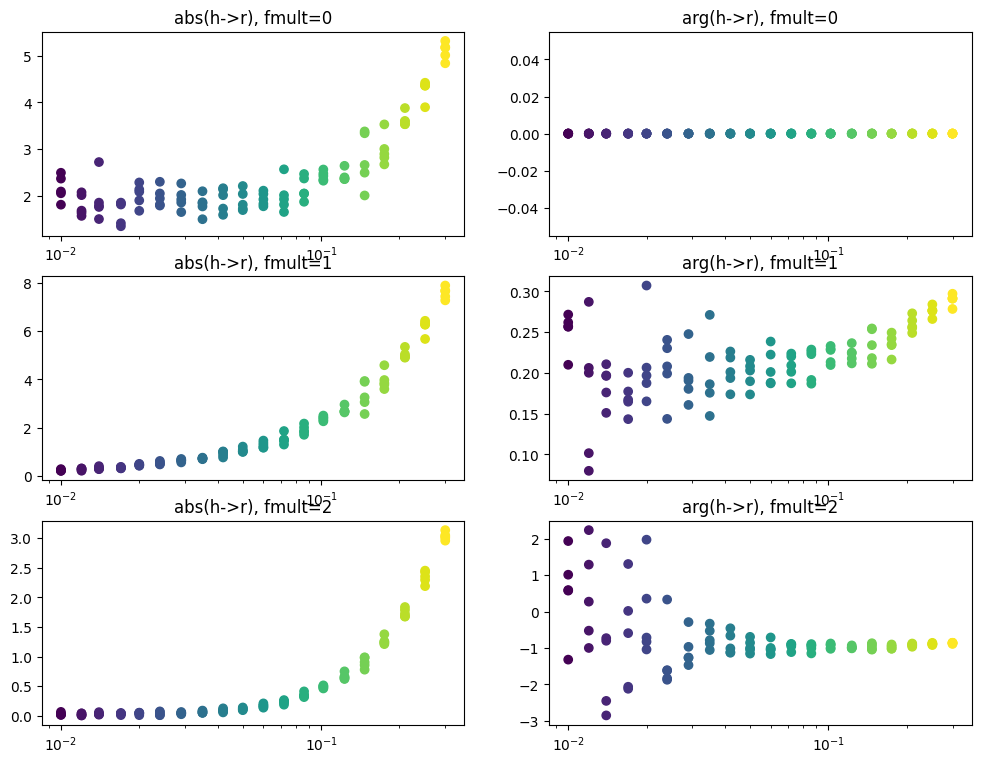

In [19]:
pop_vis = 0

nf = Q.sizes['fmult']
plt.figure(figsize=(12, 9))

for n, fmult in enumerate(Q.fmult.values):
    for seed in range(5):
        q = Q.isel(seed_main=seed, pop=pop_vis).sel(fmult=fmult).squeeze()
        q_abs = np.abs(q)
        q_arg = xr.apply_ufunc(np.angle, q)

        plt.subplot(nf, 2, 2 * n + 1)
        #q_abs.plot(linestyle='-', marker='')
        plt.scatter(q.osc_amp, q_abs, c=np.log(q.osc_amp), cmap='viridis', zorder=100)
        #plt.xlabel('osc_amp')
        plt.title(f'abs(h->r), fmult={fmult}')
        plt.semilogx()
        #plt.xticks([])

        plt.subplot(nf, 2, 2 * n + 2)
        #q_arg.plot(linestyle='-', marker='')
        plt.scatter(q.osc_amp, q_arg, c=np.log(q.osc_amp), cmap='viridis', zorder=100)
        #plt.xlabel('osc_amp')
        plt.title(f'arg(h->r), fmult={fmult}')
        plt.semilogx()
        #plt.xticks([])
        #break


In [30]:
q = np.abs(Q.isel(pop=0)).median(dim='seed_main')
#q.sel(fmult=0) - q.sel(fmult=1)
dr0 = q.sel(fmult=0) - q.sel(fmult=0).isel(osc_amp=0)
#q.sel(fmult=0)
dr0 / q.sel(fmult=1)


<xarray.DataArray (osc_f: 1, osc_amp: 20)> Size: 160B
array([[ 0.        , -1.44522798, -1.00889613, -0.8213948 , -0.01099159,
        -0.28497508, -0.26889444, -0.34921597, -0.07979891, -0.27482401,
        -0.13371461, -0.1102171 , -0.02382722,  0.13853806,  0.1064522 ,
         0.1749337 ,  0.20891082,  0.30283554,  0.36223388,  0.40282968]])
Coordinates:
  * osc_f    (osc_f) int64 8B 5
  * osc_amp  (osc_amp) float64 160B 0.01 0.012 0.014 0.017 ... 0.21 0.251 0.3
    pop      <U3 12B 'IT2'

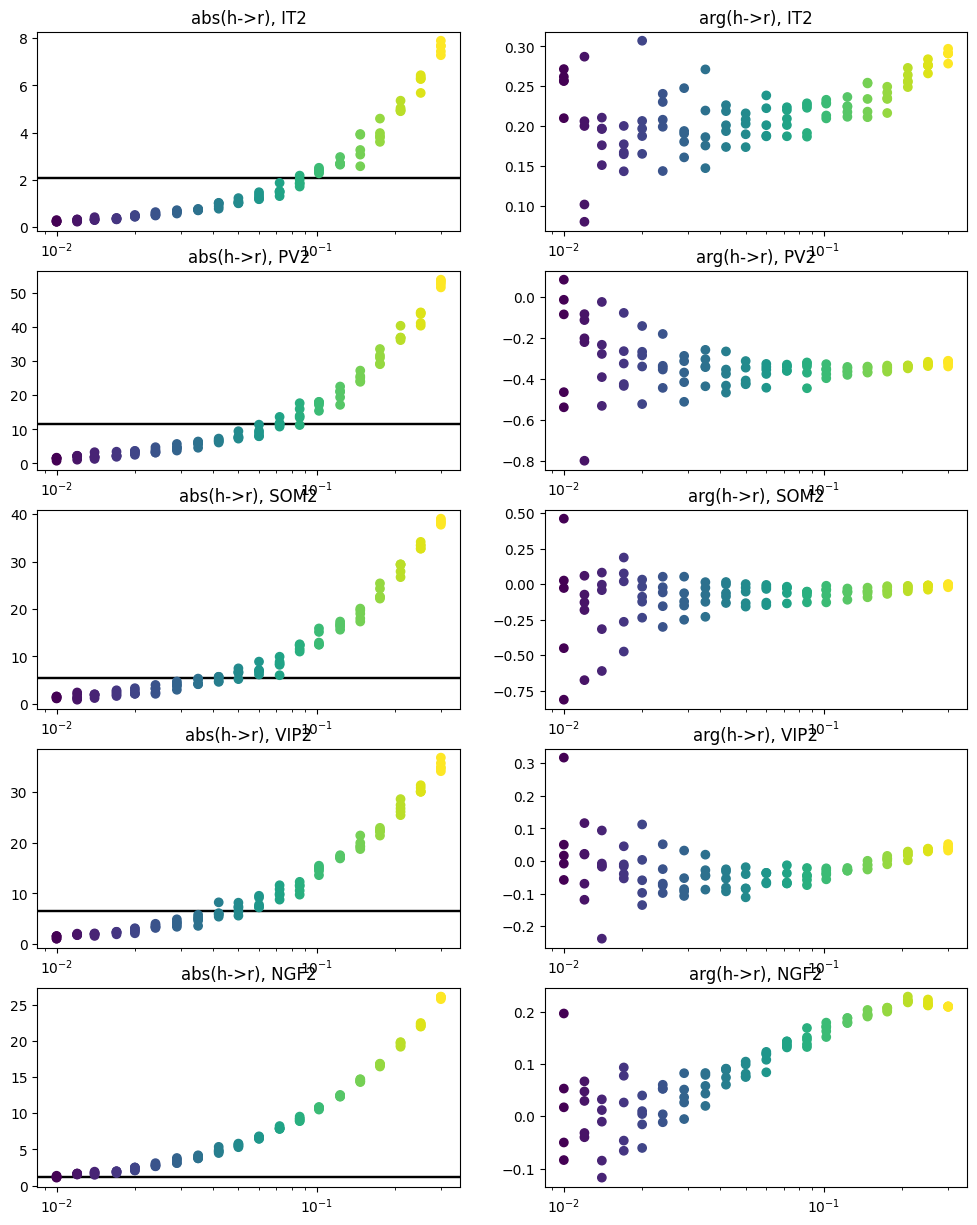

In [39]:
npops = Q.sizes['pop']

plt.figure(figsize=(12, 3 * npops))

for n, pop in enumerate(Q.pop.values):
    for seed in range(5):
        q = Q.isel(seed_main=seed).sel(fmult=1, pop=pop).squeeze()
        q_abs = np.abs(q)
        q_arg = xr.apply_ufunc(np.angle, q)

        r0 = Q.sel(fmult=0, pop=pop).median(dim='seed_main').squeeze()

        plt.subplot(npops, 2, 2 * n + 1)
        #q_abs.plot(linestyle='-', marker='')
        plt.scatter(q.osc_amp, q_abs, c=np.log(q.osc_amp), cmap='viridis', zorder=100)
        #plt.xlabel('osc_amp')
        plt.axhline(np.real(r0[0]), color='k')
        plt.title(f'abs(h->r), {pop}')
        plt.semilogx()
        #plt.xticks([])

        plt.subplot(npops, 2, 2 * n + 2)
        #q_arg.plot(linestyle='-', marker='')
        plt.scatter(q.osc_amp, q_arg, c=np.log(q.osc_amp), cmap='viridis', zorder=100)
        #plt.xlabel('osc_amp')
        plt.title(f'arg(h->r), {pop}')
        plt.semilogx()
        #plt.xticks([])
        #break
    

(0.0, 7.9292147936654835)

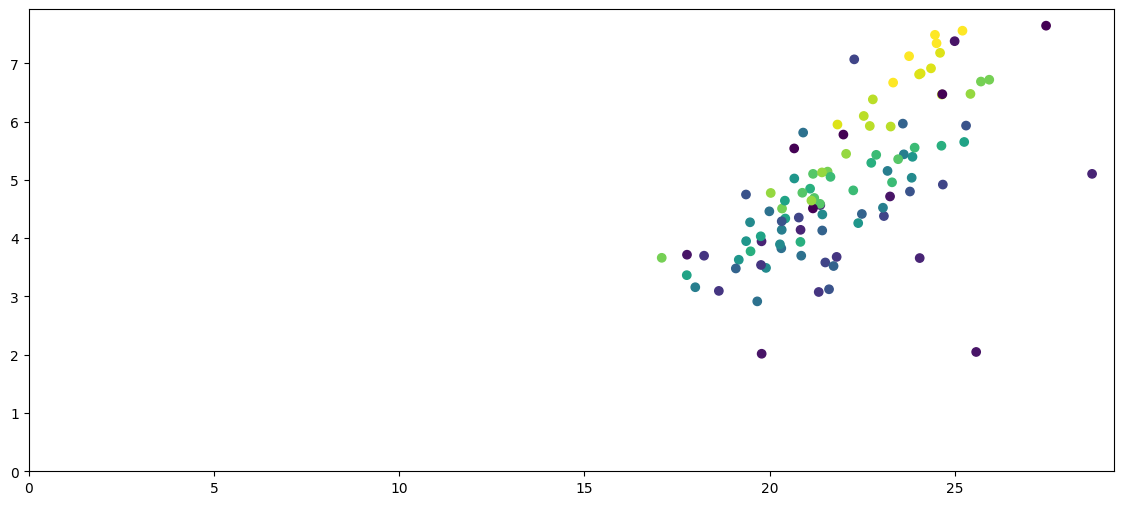

In [ ]:
plt.figure(figsize=(14, 6))

for seed in range(5):
    q = Q.isel(seed_main=seed, pop=pop_vis).sel(fmult=1).squeeze()
    q_abs = np.abs(q)
    q_arg = xr.apply_ufunc(np.angle, q)

    #plt.plot(q.real, q.imag, alpha=0.5)
    plt.scatter(q.real, q.imag, c=np.log(q.osc_amp.values), cmap='viridis', zorder=100)
    #plt.scatter(q.real.values, q.imag.values, c=np.angle(q), cmap='viridis', zorder=100)

#plt.colorbar(label='osc_amp')
#plt.colorbar(label='phase')
plt.xlim(0, None)
plt.ylim(0, None)
#plt.semilogx()
#plt.semilogy()